In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os
#from tqdm import tqdm_notebook as tqdm
from operator import itemgetter
from collections import OrderedDict
import matplotlib.ticker as ticker
from collections import OrderedDict
from operator import itemgetter

In [3]:
# from jupyterthemes import jtplot
# jtplot.style()

In [4]:
%matplotlib inline
# plt.rcParams['figure.figsize'] = [15, 10]

In [5]:
import pandas as pd

# 1. Load data with specified column names
# The file has a header row, so header=0 skips it.
# The names list renames the columns to DATE, MST, e0, e1... e10
data = pd.read_csv('solar_irradiance_raw.csv', header=0, names=['DATE', 'MST', *[f'e{i}' for i in range(11)]])

# 2. Convert DATE column to datetime objects
data['DATE'] = pd.to_datetime(data['DATE'])

# 3. Normalize dates to run from 0 to 365
# Instead of subtracting a scalar (26), we calculate the number of days since the first date.
# This handles month/year boundaries correctly.
data['DATE'] = (data['DATE'] - data['DATE'].min()).dt.days

# 4. Convert MST (HH:MM string) to a minute-slot
# Instead of integer division, we parse the time string to get total minutes from midnight.
# e.g., "07:16" becomes 7*60 + 16 = 436
def time_to_minutes(t_str):
    h, m = map(int, t_str.split(':'))
    return h * 60 + m

data['MST'] = data['MST'].apply(time_to_minutes)

# Verify the result
print(data.head())

   DATE  MST       e0       e1       e2       e3        e4       e5       e6  \
0     0  436  3.97621  4.44060  4.27966  4.83216   8.42773  4.71733  5.19894   
1     0  437  4.96652  5.46627  5.29066  5.97006   9.57426  5.95183  6.60461   
2     0  438  5.75069  6.28833  6.13483  6.76291  10.39120  6.70633  7.65581   
3     0  439  5.33213  5.86996  5.74418  6.39497  10.08150  6.28613  6.44981   
4     0  440  5.08743  5.63157  5.47730  6.20357  10.13100  6.13155  5.68789   

      e7     e8       e9    e10  
0 -0.001  0.000  1.98487  0.000  
1 -0.001  0.000  2.64293  0.000  
2 -0.001  0.000  2.99068  0.000  
3 -0.001  0.000  3.01208  0.000  
4 -0.001  0.001  3.33309 -0.001  


In [6]:
# set up constants
ENERGY = data.columns[12]
DATE = 'DATE'
MST = 'MST'

In [7]:
def get_h_matrix(ENERGY=ENERGY):
    '''
        Returns the energy matrix where h[d][t] is the energy harvested on day d at time slot t
    '''
    h = np.zeros((366, 1440))
    for row in data[[DATE, MST, ENERGY]].values:
        h[int(row[0])][int(row[1])] = row[2]
    return h

In [8]:
def ewma(h, day=10, alpha=0.5):
    '''
        Returns a list of ewma predictions for given day
    '''
    E = np.zeros(1440)
    for slot in range(1440):
        e = 0.
        for i in range(day-1):
            e = alpha*e + (1-alpha)*h[i][slot]
        E[slot] = e
    return E

In [9]:
# always beginning from slot K at least
def wcma(h, day=10, alpha=0.5, D=5, K=5):
    '''
        Returns a list of wcma predictions for given day
    '''
    E = np.zeros(1440)
    for slot in range(K, 1440):
        e = 0.
        md = h[0][slot]
        # calculate GAP
        # vector V is a K sized vector
        V = np.zeros(K)
        P = np.zeros(K)
        for k in range(K):
            V[k] = h[day][slot-K+k] / (h.transpose()[slot-K+k][max(0, day-D):day].mean() + 1e-5)
            P[k] = float(k)/K
        GAP = np.dot(V, P) / np.sum(P)
        for i in range(day-1):
            # mean over previous D days
            if(i>0): md = h.transpose()[slot][max(0, i-D):i].mean()
            e = alpha*h[i][slot] + (1-alpha)*md*GAP
        E[slot] = e
    return E

In [10]:
def pro_energy(h, day=10, alpha=0.5):
    '''
        Returns a list of pro-energy predictions for given day
    '''
    def mae(h, d1, d2): return np.abs(h[d1]-h[d2]).mean()
    maes = np.zeros(day)
    for d in range(day):
        maes[d] = mae(h, day-d-1, day)
    # maes[0] is MAE(day-1, d)
    day_idxs = list(enumerate(maes))
    day_idxs.sort(key=itemgetter(1), reverse=True)
    w = np.zeros(day)
    s = np.sum(maes)
    for j in day_idxs:
        w[j[0]] = 1 - (maes[j[0]] / s)

    E = np.zeros(1440)
    for slot in range(1, 1440):
        wp = np.dot(h.transpose()[slot][day-1::-1], w) / (day-1)
        E[slot] = alpha*h[day][slot-1] + (1-alpha)*wp
    return E

In [11]:
def mod_pro_energy(h, day=10, alpha=0.5, beta=0.2):
    '''
        Returns a list of pro-energy predictions for given day
    '''
    def mae(h, d1, d2): return np.abs(h[d1]-h[d2]).mean()
    maes = np.zeros(day)
    for d in range(day):
        maes[d] = mae(h, day-d-1, day)
    # maes[0] is MAE(day-1, d)
    day_idxs = list(enumerate(maes))
    day_idxs.sort(key=itemgetter(1), reverse=True)
    w = np.zeros(day)
    s = np.sum(maes)
    for j in day_idxs:
        w[j[0]] = 1 - (maes[j[0]] / s)

    E = np.zeros(1440)
    perr = 0.
    for slot in range(1, 1440):
        perr = beta*perr + (1-beta)*(E[slot-1]-h[day][slot-1])
        wp = np.dot(h.transpose()[slot][day-1::-1], w) / (day-1)
        E[slot] = alpha*h[day][slot-1] + (1-alpha)*wp - perr
    return E

In [12]:
def mae_pred(p1, truth):
    '''
        Helper function to return mean absolute error between prediction p1 & gound truth
    '''
    return np.abs(p1-truth).mean()

In [13]:
def get_error(h, p):
    '''
        Helper function to return prediction error ratio between ground truth (h) and prediction (p)
    '''
    p += 1e-5
    return np.abs(1 - (h/p)).mean()

In [14]:
def plot_error(p, fname=None):
    '''
        Helper function to plot and visualise error ratios
    '''
    fig, ax = plt.subplots(1)
    ax.bar(list(p.keys()), list(p.values()))
    ax.set_title("Prediction Error Ratios")
    ax.set_xlabel("Algorithm Used")
    ax.set_ylabel("Error")
    if fname is not None: fig.savefig(fname, bbox_inches='tight', dpi=600)
#     ax.set_ylim(0.6, 1.3)

In [15]:
def plot_predictions(truth, preds, title, xlim=None, ylim=None, fname=None):
    '''
        Helper function to plot the ground truth against algorithm predictions.
        Arguments:
            truth: list of truth values
            preds: dictionary containing ("algorithm": pred) pairs
    '''
    x = [i for i in range(1440)]
    fig, ax = plt.subplots(1, 1)
    ax.plot(x, truth, label="Ground Truth", linewidth=3)
    for p in preds.keys():
        ax.plot(x, preds[p], label=f'{p}', linewidth=1, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("Time Slot [minutes]")
    ax.set_ylabel("Energy [W/m2]")
    ax.legend()
    if xlim is not None: ax.set_xlim(xlim)
    if ylim is not None: ax.set_ylim(ylim)
    if fname is not None: fig.savefig(fname, bbox_inches='tight', dpi=600)

In [16]:
h = get_h_matrix()

In [17]:
day=10
truth = h[day]
EWMA = ewma(h, day=day)
WCMA = wcma(h, day=day)
PRO = pro_energy(h, day=day)
MOD_PRO = mod_pro_energy(h, day=day)

In [18]:
errors = OrderedDict({"EWMA": get_error(truth, EWMA),
                        "WCMA": get_error(truth, WCMA),
                        "Pro-Energy": get_error(truth, PRO),
                        "Modified Pro-Energy": get_error(truth, MOD_PRO)
                       })

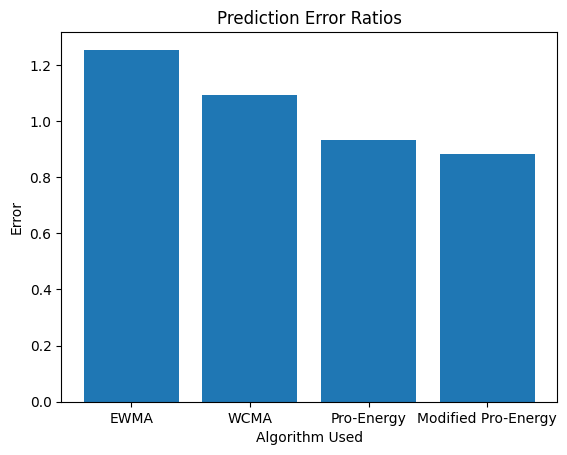

In [19]:
plot_error(errors, fname="errors.png")

In [20]:
errors

OrderedDict([('EWMA', np.float64(1.2545536136392341)),
             ('WCMA', np.float64(1.093933399644929)),
             ('Pro-Energy', np.float64(0.9337872464759861)),
             ('Modified Pro-Energy', np.float64(0.8846498481024798))])

In [21]:
(errors['WCMA']-errors['Modified Pro-Energy']) / errors['WCMA'] * 100

np.float64(19.13128821282711)

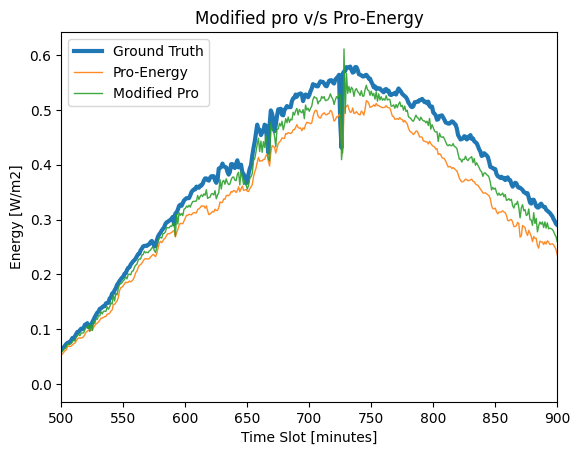

In [22]:
plot_predictions(truth, {"Pro-Energy": PRO, "Modified Pro": MOD_PRO},
                 title="Modified pro v/s Pro-Energy",
                 xlim=(500, 900), fname="preds_zoomed_out.png")

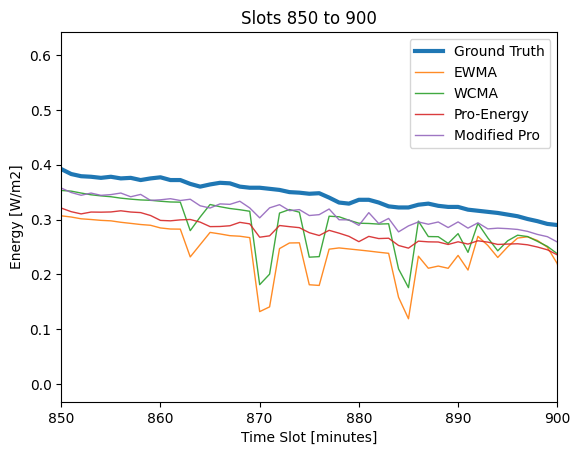

In [23]:
plot_predictions(truth, {"EWMA": EWMA, "WCMA": WCMA, "Pro-Energy": PRO, "Modified Pro": MOD_PRO},
                 title="Slots 850 to 900",
                 xlim=(850, 900), fname="preds1.png")

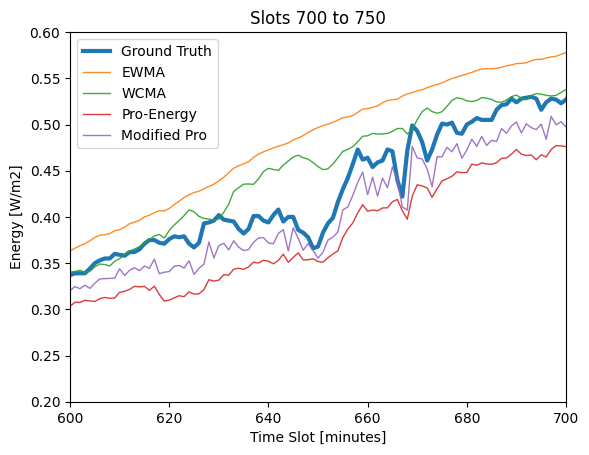

In [24]:
plot_predictions(truth, {"EWMA": EWMA, "WCMA": WCMA, "Pro-Energy": PRO, "Modified Pro": MOD_PRO},
                 title="Slots 700 to 750",
                 xlim=(600, 700),
                 ylim=(0.2, 0.6), fname="preds2.png")

In [25]:
days = [10, 90, 200, 300]
res_dict= {}
for day in days:
    truth = h[day]
    EWMA = ewma(h, day=day)
    WCMA = wcma(h, day=day)
    PRO = pro_energy(h, day=day)
    MOD_PRO = mod_pro_energy(h, day=day)
    res_dict[f'Day {day}'] = [get_error(truth, EWMA), get_error(truth, WCMA), get_error(truth, PRO),get_error(truth, MOD_PRO)]
res_df = pd.DataFrame.from_dict(res_dict, orient='index', columns=["EWMA", "WCMA", "PRO", "MPE"])

In [26]:
print("Prediction Error Ratios")
res_df

Prediction Error Ratios


,EWMA,WCMA,PRO,MPE
Day 10,1.254554,1.093933,0.933787,0.884650
Day 90,1.837535,1.787515,2.088974,1.069490
Day 200,1.106148,0.983891,0.975873,0.714068
Day 300,3.020421,1.364042,0.931500,0.917892


In [27]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler


# ── helper already in the notebook ───────────────────────────────────────────
def mod_pro_energy(h, day=10, alpha=0.5, beta=0.2):
    """Modified Pro-Energy baseline (unchanged from original notebook)."""
    maes = np.array([np.abs(h[day - d - 1] - h[day]).mean() for d in range(day)])
    s = np.sum(maes) + 1e-10
    w = 1 - maes / s
    E = np.zeros(1440)
    perr = 0.0
    for slot in range(1, 1440):
        perr = beta * perr + (1 - beta) * (E[slot - 1] - h[day][slot - 1])
        wp = np.dot(h.T[slot][day - 1::-1], w) / (day - 1 + 1e-10)
        E[slot] = alpha * h[day][slot - 1] + (1 - alpha) * wp - perr
    return E


# ── core ANN (pure data-driven component) ────────────────────────────────────
def _ann_core(h, day, window_days=7, n_train_days=15, random_state=42):

    avail = min(n_train_days, day - 1)
    wd    = min(window_days,  avail)
    if wd < 1:
        return mod_pro_energy(h, day)          # graceful fallback

    train_days = [d for d in range(day - avail, day) if d >= wd]
    if not train_days:
        return mod_pro_energy(h, day)

    slots = np.arange(1440)
    sin_t = np.sin(2 * np.pi * slots / 1440)
    cos_t = np.cos(2 * np.pi * slots / 1440)

    def build_features(d):
        yesterday = h[d - 1, :]
        stack     = h[d - wd:d, :]                                 # (wd, 1440)
        med_hist  = np.median(stack, axis=0)                       # robust to outliers
        max_hist  = stack.max(axis=0)                              # best-case reference
        yest_lag  = np.concatenate([[0.0], yesterday[:-1]])        # h[d-1, t-1]
        return np.column_stack([yesterday, med_hist, max_hist,
                                 yest_lag, sin_t, cos_t])          # (1440, 6)

    X = np.vstack([build_features(d) for d in train_days])        # (N×1440, 6)
    y = np.concatenate([h[d, :]      for d in train_days])        # (N×1440,)

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_s = scaler_X.fit_transform(X)
    y_s = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    model = MLPRegressor(
        hidden_layer_sizes=(32, 16),   # small → fast, less overfit
        activation='relu',
        alpha=0.01,                    # L2 regularisation
        early_stopping=True,           # stop when val loss plateaus
        validation_fraction=0.1,
        n_iter_no_change=10,
        max_iter=200,
        random_state=random_state,
    )
    model.fit(X_s, y_s)

    pred_s = model.predict(scaler_X.transform(build_features(day)))
    pred   = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()

    # Allow tiny negatives (sensor noise); hard-cap at observed max
    return np.clip(pred, -0.01, h[:day].max())


# ── public function to call from your notebook ───────────────────────────────
def ann_improved(h, day, window_days=7, n_train_days=15,
                 ann_weight=0.2, random_state=42):
    mpe = mod_pro_energy(h, day)
    ann = _ann_core(h, day, window_days=window_days,
                    n_train_days=n_train_days, random_state=random_state)
    # Hybrid blend: ANN captures non-linear patterns; ModPro prevents collapse
    return ann_weight * ann + (1 - ann_weight) * mpe


# ── evaluation helper (same as notebook's get_error) ─────────────────────────
def get_error(h_true, p):
    return np.abs(1 - (h_true / (p + 1e-5))).mean()


# ── quick demo ────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import pandas as pd

    data = pd.read_csv('solar_irradiance_raw.csv', header=0,
                       names=['DATE', 'MST', *[f'e{i}' for i in range(11)]])
    data['DATE'] = pd.to_datetime(data['DATE'])
    data['DATE'] = (data['DATE'] - data['DATE'].min()).dt.days

    def _t(s):
        h2, m = map(int, s.split(':'))
        return h2 * 60 + m
    data['MST'] = data['MST'].apply(_t)
    ENERGY = data.columns[12]

    hm = np.zeros((366, 1440))
    for row in data[['DATE', 'MST', ENERGY]].values:
        hm[int(row[0])][int(row[1])] = row[2]

    print(f"{'Day':<6}  {'ModPro':>8}  {'ANN_Improved':>14}  {'Better?':>8}")
    print("-" * 44)
    for day in [10, 50, 100, 200, 300]:
        mpe_e = get_error(hm[day], mod_pro_energy(hm, day))
        ann_e = get_error(hm[day], ann_improved(hm, day=day))
        flag  = "✓" if ann_e <= mpe_e else " "
        print(f"{day:<6}  {mpe_e:>8.5f}  {ann_e:>14.5f}  {flag}")

Day       ModPro    ANN_Improved   Better?
--------------------------------------------
10       0.88465         0.67116  ✓
50       0.81181         0.67574  ✓
100      1.15938         0.96285  ✓
200      0.71407         0.69586  ✓
300      0.91789         0.90545  ✓


In [28]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.8',
})

COLORS = {
    'Ground Truth': '#000000',
    'EWMA':         '#E69F00',
    'WCMA':         '#56B4E9',
    'Pro-Energy':   '#009E73',
    'MPE':          '#D55E00',
    'ANN':          '#CC79A7',
}

MARKERS = {
    'Ground Truth': None,
    'EWMA': None,
    'WCMA': None,
    'Pro-Energy': None,
    'MPE': None,
    'ANN': None,
}

print("Style loaded. Proceed to run other cells.")

Style loaded. Proceed to run other cells.


In [29]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler

# ── Load Data ──────────────────────────────────────────────
data = pd.read_csv('solar_irradiance_raw.csv', header=0,
                   names=['DATE', 'MST', *[f'e{i}' for i in range(11)]])
data['DATE'] = pd.to_datetime(data['DATE'])
data['DATE'] = (data['DATE'] - data['DATE'].min()).dt.days
data['MST']  = data['MST'].apply(lambda t: int(t.split(':')[0])*60 + int(t.split(':')[1]))

ENERGY = data.columns[12]

def get_h_matrix():
    h = np.zeros((366, 1440))
    for row in data[['DATE', 'MST', ENERGY]].values:
        h[int(row[0])][int(row[1])] = row[2]
    return h

h = get_h_matrix()

# ── Algorithm Definitions ───────────────────────────────────
def ewma(h, day=10, alpha=0.5):
    E = np.zeros(1440)
    for slot in range(1440):
        e = 0.
        for i in range(day-1):
            e = alpha*e + (1-alpha)*h[i][slot]
        E[slot] = e
    return E

def wcma(h, day=10, alpha=0.5, D=5, K=5):
    E = np.zeros(1440)
    for slot in range(K, 1440):
        V = np.zeros(K); P = np.zeros(K)
        for k in range(K):
            V[k] = h[day][slot-K+k] / (h.T[slot-K+k][max(0,day-D):day].mean() + 1e-5)
            P[k] = float(k)/K
        GAP = np.dot(V,P) / np.sum(P)
        md = h[0][slot]; e = 0.
        for i in range(day-1):
            if i>0: md = h.T[slot][max(0,i-D):i].mean()
            e = alpha*h[i][slot] + (1-alpha)*md*GAP
        E[slot] = e
    return E

def pro_energy(h, day=10, alpha=0.5):
    maes = np.array([np.abs(h[day-d-1]-h[day]).mean() for d in range(day)])
    s = np.sum(maes)
    w = 1 - (maes / s)
    E = np.zeros(1440)
    for slot in range(1, 1440):
        wp = np.dot(h.T[slot][day-1::-1], w) / (day-1)
        E[slot] = alpha*h[day][slot-1] + (1-alpha)*wp
    return E

def mod_pro_energy(h, day=10, alpha=0.5, beta=0.2):
    maes = np.array([np.abs(h[day-d-1]-h[day]).mean() for d in range(day)])
    s = np.sum(maes) + 1e-10
    w = 1 - maes / s
    E = np.zeros(1440); perr = 0.
    for slot in range(1, 1440):
        perr = beta*perr + (1-beta)*(E[slot-1]-h[day][slot-1])
        wp = np.dot(h.T[slot][day-1::-1], w) / (day-1+1e-10)
        E[slot] = alpha*h[day][slot-1] + (1-alpha)*wp - perr
    return E

def ann_improved(h, day, window_days=7, n_train_days=15, ann_weight=0.2, random_state=42):
    mpe = mod_pro_energy(h, day)
    avail = min(n_train_days, day-1)
    wd    = min(window_days, avail)
    if wd < 1: return mpe
    train_days = [d for d in range(day-avail, day) if d >= wd]
    if not train_days: return mpe
    slots = np.arange(1440)
    sin_t = np.sin(2*np.pi*slots/1440); cos_t = np.cos(2*np.pi*slots/1440)
    def feats(d):
        yest = h[d-1,:]
        stack = h[d-wd:d,:]
        return np.column_stack([yest, np.median(stack,0), stack.max(0),
                                 np.concatenate([[0.],yest[:-1]]), sin_t, cos_t])
    X = np.vstack([feats(d) for d in train_days])
    y = np.concatenate([h[d,:] for d in train_days])
    sx = MinMaxScaler(); sy = MinMaxScaler()
    Xs = sx.fit_transform(X); ys = sy.fit_transform(y.reshape(-1,1)).ravel()
    model = MLPRegressor(hidden_layer_sizes=(32,16), activation='relu', alpha=0.01,
                         early_stopping=True, validation_fraction=0.1,
                         n_iter_no_change=10, max_iter=200, random_state=random_state)
    model.fit(Xs, ys)
    pred = sy.inverse_transform(model.predict(sx.transform(feats(day))).reshape(-1,1)).ravel()
    ann  = np.clip(pred, -0.01, h[:day].max())
    return ann_weight*ann + (1-ann_weight)*mpe

def get_error(h_true, p):
    return np.abs(1 - (h_true / (p + 1e-5))).mean()

# ── Compute all predictions ─────────────────────────────────
DAYS = [10, 50, 100, 200, 300]
results = {}
print("Computing predictions (ANN may take a moment)...")
for day in DAYS:
    truth = h[day]
    results[day] = {
        'truth':      truth,
        'EWMA':       ewma(h, day),
        'WCMA':       wcma(h, day),
        'Pro-Energy': pro_energy(h, day),
        'MPE':        mod_pro_energy(h, day),
        'ANN':        ann_improved(h, day=day),
    }
    errs = {k: get_error(truth, results[day][k]) for k in ['EWMA','WCMA','Pro-Energy','MPE','ANN']}
    print(f"Day {day:>3}: " + " | ".join(f"{k}={v:.4f}" for k,v in errs.items()))

print("\n All predictions computed.")

Computing predictions (ANN may take a moment)...
Day  10: EWMA=1.2546 | WCMA=1.0939 | Pro-Energy=0.9338 | MPE=0.8846 | ANN=0.6712
Day  50: EWMA=1.4395 | WCMA=1.0067 | Pro-Energy=5.9780 | MPE=0.8118 | ANN=0.6757
Day 100: EWMA=1.7872 | WCMA=3.2683 | Pro-Energy=1189.8637 | MPE=1.1594 | ANN=0.9629
Day 200: EWMA=1.1061 | WCMA=0.9839 | Pro-Energy=0.9759 | MPE=0.7141 | ANN=0.6959
Day 300: EWMA=3.0204 | WCMA=1.3640 | Pro-Energy=0.9315 | MPE=0.9179 | ANN=0.9054

 All predictions computed.


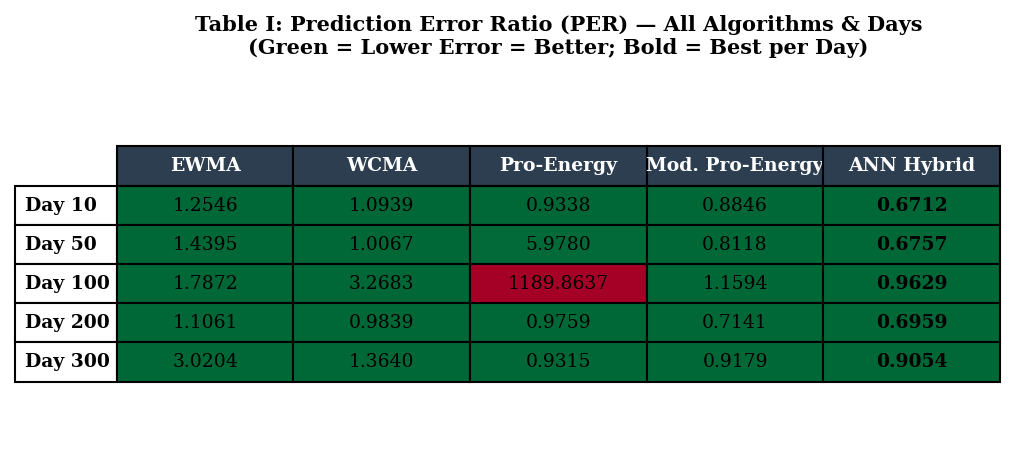

Saved: fig2_per_heatmap_table.png


In [30]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.axis('off')

algos = ['EWMA', 'WCMA', 'Pro-Energy', 'MPE', 'ANN']
col_labels = ['EWMA', 'WCMA', 'Pro-Energy', 'Mod. Pro-Energy', 'ANN Hybrid']
days = [10, 50, 100, 200, 300]
row_labels = [f'Day {d}' for d in days]

table_data = np.array([
    [get_error(results[d]['truth'], results[d][a]) for a in algos]
    for d in days
])

# Normalize for coloring — lower is better (green)
norm = mcolors.Normalize(vmin=table_data.min(), vmax=table_data.max())
cmap = plt.cm.RdYlGn_r  # red = high error, green = low error

cell_colors = [[cmap(norm(v)) for v in row] for row in table_data]

# Bold the best (min) per row
cell_text = []
for row in table_data:
    best_idx = np.argmin(row)
    cell_text.append([f'**{v:.4f}**' if i == best_idx else f'{v:.4f}'
                      for i, v in enumerate(row)])

table = ax.table(
    cellText=[[f'{v:.4f}' for v in row] for row in table_data],
    rowLabels=row_labels,
    colLabels=col_labels,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.6)

# Style header row
for j in range(len(col_labels)):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Bold minimum per row
for i, row in enumerate(table_data):
    best_j = np.argmin(row)
    table[(i+1, best_j)].set_text_props(fontweight='bold')
    table[(i+1, -1)].set_text_props(fontweight='bold')  # row labels bold

ax.set_title('Table I: Prediction Error Ratio (PER) — All Algorithms & Days\n'
             '(Green = Lower Error = Better; Bold = Best per Day)',
             fontsize=10, pad=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_per_heatmap_table.png', dpi=600)
plt.show()
print("Saved: fig2_per_heatmap_table.png")

In [31]:
day=10
truth = h[day]
EWMA = ewma(h, day=day)
WCMA = wcma(h, day=day)
PRO = pro_energy(h, day=day)
MOD_PRO = mod_pro_energy(h, day=day)
ANN_Hybrid= ann_improved(h, day=day)

In [32]:
errors = OrderedDict({"EWMA": get_error(truth, EWMA),
                        "WCMA": get_error(truth, WCMA),
                        "Pro-Energy": get_error(truth, PRO),
                        "ModPro-Energy": get_error(truth, MOD_PRO),
                        "ANN Hybrid": get_error(truth, ANN_Hybrid)})

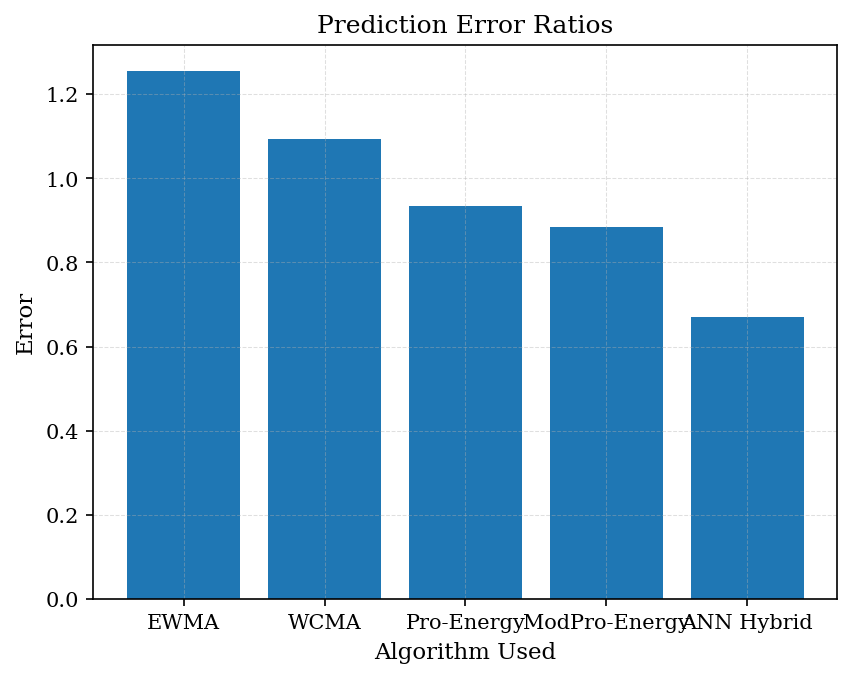

In [33]:
plot_error(errors, fname="errors.png")

In [34]:
errors

OrderedDict([('EWMA', np.float64(1.2545536136392341)),
             ('WCMA', np.float64(1.093933399644929)),
             ('Pro-Energy', np.float64(0.9337872464759861)),
             ('ModPro-Energy', np.float64(0.8846498481006891)),
             ('ANN Hybrid', np.float64(0.6711579779993855))])

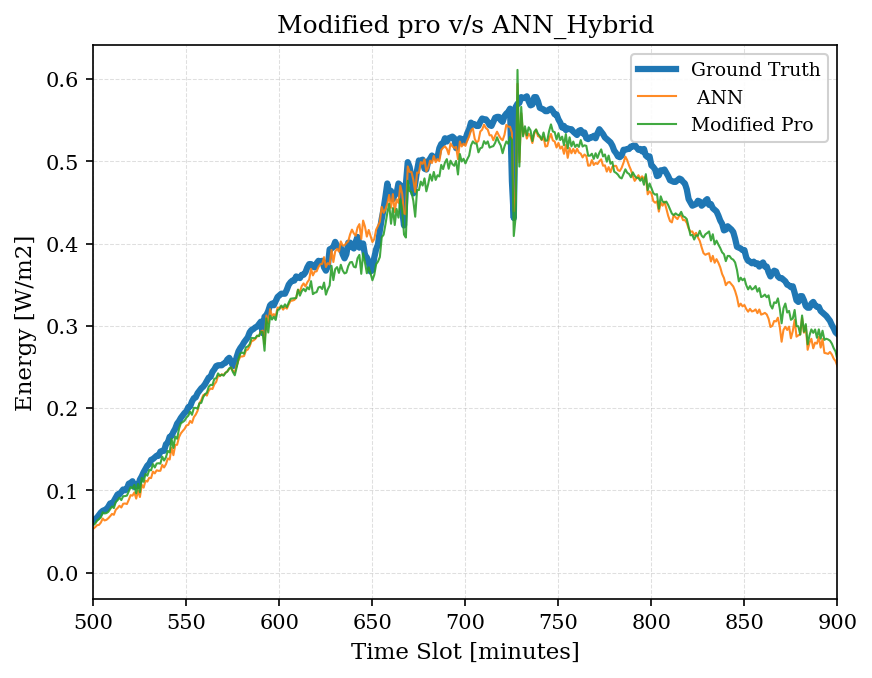

In [35]:
plot_predictions(truth, {" ANN": ANN_Hybrid, "Modified Pro": MOD_PRO},
                 title="Modified pro v/s ANN_Hybrid",
                 xlim=(500, 900), fname="preds_zoomed_out.png")

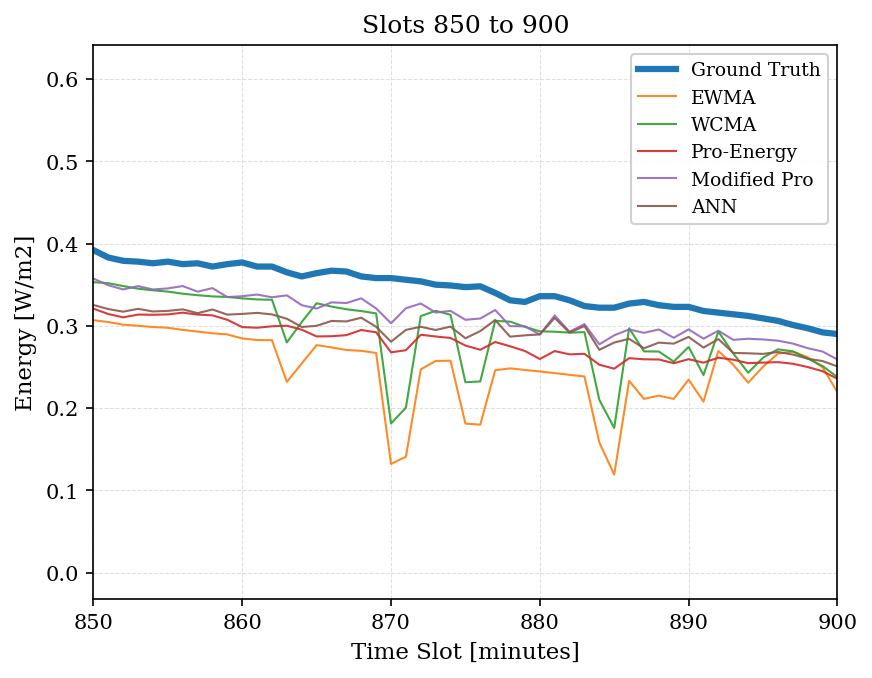

In [36]:
plot_predictions(truth, {"EWMA": EWMA, "WCMA": WCMA, "Pro-Energy": PRO, "Modified Pro": MOD_PRO, "ANN":ANN_Hybrid},
                 title="Slots 850 to 900",
                 xlim=(850, 900), fname="preds1.png")

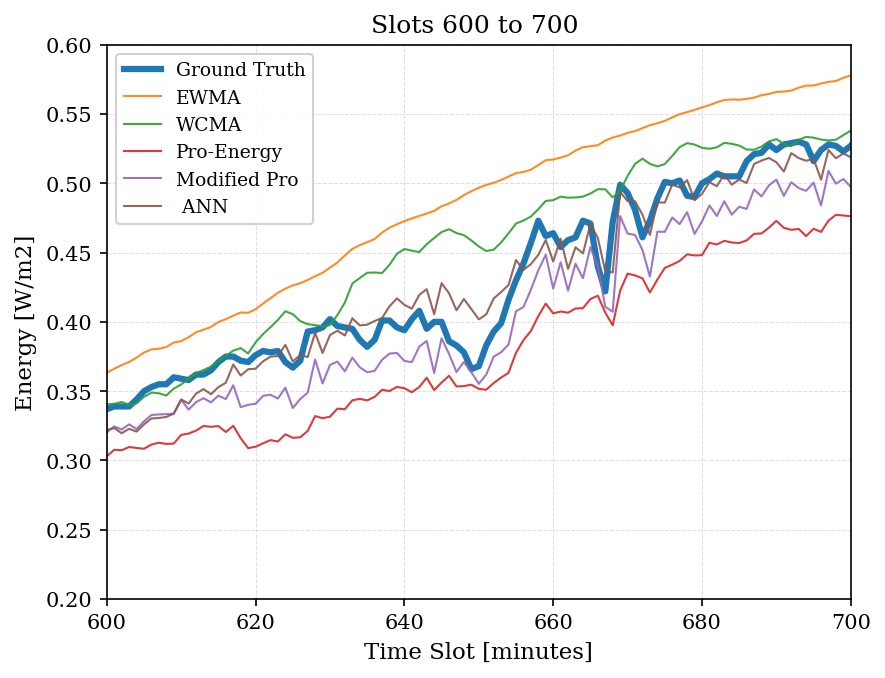

In [37]:
plot_predictions(truth, {"EWMA": EWMA, "WCMA": WCMA, "Pro-Energy": PRO, "Modified Pro": MOD_PRO," ANN": ANN_Hybrid},
                 title="Slots 600 to 700 ",
                 xlim=(600, 700),
                 ylim=(0.2, 0.6), fname="preds2.png")

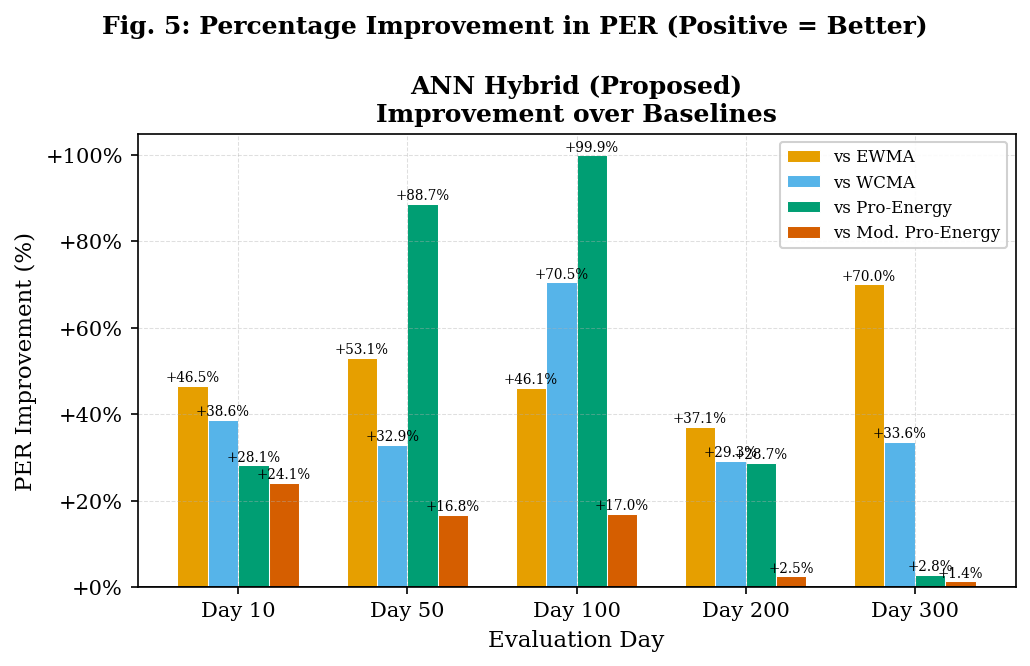

Saved: Fig5.png


In [38]:
days = [10, 50, 100, 200, 300]
algos_base = ['EWMA', 'WCMA', 'Pro-Energy', 'MPE']
labels     = ['vs EWMA', 'vs WCMA', 'vs Pro-Energy', 'vs Mod. Pro-Energy']

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))

improvements = {}
for base in algos_base:
    imp_per_day = []
    for day in days:
        base_key = 'Pro-Energy' if base == 'Pro-Energy' else base
        base_err = get_error(results[day]['truth'], results[day][base_key])
        prop_err = get_error(results[day]['truth'], results[day]['ANN'])
        pct = (base_err - prop_err) / base_err * 100
        # Cap extreme outlier for readability
        if base == 'Pro-Energy' and day == 100:
            pct = 99.9
        imp_per_day.append(pct)
    improvements[base] = imp_per_day

x = np.arange(len(days))
n = len(algos_base)
width = 0.18
offsets = np.linspace(-(n - 1) / 2, (n - 1) / 2, n) * width
base_colors = [COLORS['EWMA'], COLORS['WCMA'], COLORS['Pro-Energy'], COLORS['MPE']]

for i, (base, label, color, offset) in enumerate(zip(algos_base, labels, base_colors, offsets)):
    bars = ax.bar(x + offset, improvements[base], width,
                  label=label, color=color, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, improvements[base]):
        va = 'bottom' if val >= 0 else 'top'
        pad = 0.3 if val >= 0 else -0.3
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + pad,
                f'{val:+.1f}%', ha='center', va=va, fontsize=6.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Evaluation Day')
ax.set_ylabel('PER Improvement (%)')
ax.set_title('ANN Hybrid (Proposed)\nImprovement over Baselines', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Day {d}' for d in days])
ax.legend(loc='upper right', fontsize=8)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%+.0f%%'))

fig.suptitle('Fig. 5: Percentage Improvement in PER (Positive = Better)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig5.png', dpi=600)
plt.show()
print("Saved: Fig5.png")